In [1]:
!pip install biopython
!apt-get install -y mafft
!apt-get install -y raxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-lato libauthen-sasl-perl libclone-perl libdata-dump-perl
  libencode-locale-perl libfile-listing-perl libfont-afm-perl
  libhtml-form-perl libhtml-format-perl libhtml-parser-perl
  libhtml-tagset-perl libhtml-tree-perl libhttp-cookies-perl
  libhttp-daemon-perl libhttp-date-perl libhttp-message-perl
  libhttp-negotiate-perl libio-html-perl libio-socket-ssl-perl
  liblwp-mediatypes-perl liblwp-protocol-https-perl libmailtools-perl
  libnet-http-perl libnet-smtp-ssl-perl libnet-ssleay-perl libruby3.0
  libtry-tiny-perl liburi-perl libwww-perl libwww-robotrules-perl lynx
  lynx-common netbase perl-openssl-defaults rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration
Suggested packages:
  libdigest-hmac-perl libgssap

In [3]:
from google.colab import files

uploaded = files.upload()

Saving kinesin_motor.fasta to kinesin_motor.fasta
Saving kinesin14.fasta to kinesin14.fasta


In [4]:
import os

os.listdir()

['.config', 'kinesin_motor.fasta', 'kinesin14.fasta', 'sample_data']

In [5]:
from Bio import SeqIO

for file in ["kinesin_motor.fasta", "kinesin14.fasta"]:
    print("\nFILE:", file)

    for record in SeqIO.parse(file, "fasta"):
        print(record.id)


FILE: kinesin_motor.fasta
sp|O00139|KIF2A_HUMAN
sp|O15066|KIF3B_HUMAN
sp|P52732|KIF11_HUMAN
sp|Q02241|KIF23_HUMAN
sp|Q12840|KIF5A_HUMAN
sp|Q96Q89|KI20B_HUMAN
sp|Q9H1H9|KI13A_HUMAN
sp|Q9NQT8|KI13B_HUMAN
sp|Q9P2E2|KIF17_HUMAN
sp|Q9Y496|KIF3A_HUMAN

FILE: kinesin14.fasta
sp|O14782|KIF3C_HUMAN
sp|O43896|KIF1C_HUMAN
sp|Q15058|KIF14_HUMAN
sp|Q5T7B8|KIF24_HUMAN
sp|Q86VH2|KIF27_HUMAN
sp|Q99661|KIF2C_HUMAN


In [6]:
!mafft --auto kinesin_motor.fasta > kinesin_motor_aligned.fasta

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.490
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 10
done.

Progressive alignment ... 
STEP     7 /9 
Reallocating..done. *alloclen = 4876
STEP     9 /9 
done.
tbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 10
Segment   1/  1    1-2560
STEP 007-007-0  rejected.
Oscillating.

done
dvtditr (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:


In [7]:
!mafft --auto kinesin14.fasta > kinesin14_aligned.fasta

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.490
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 6
done.

Progressive alignment ... 
STEP     4 /5 
Reallocating..done. *alloclen = 4470
STEP     5 /5 
done.
tbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 6
Segment   1/  1    1-2132
STEP 004-003-0  rejected.
Converged.

done
dvtditr (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-I

In [8]:
from Bio import AlignIO

alignment = AlignIO.read("kinesin_motor_aligned.fasta", "fasta")
AlignIO.write(alignment, "kinesin_motor_aligned.phy", "phylip-relaxed")

alignment = AlignIO.read("kinesin14_aligned.fasta", "fasta")
AlignIO.write(alignment, "kinesin14_aligned.phy", "phylip-relaxed")

1

Use raxml with AVX support (1 cpus)

You can specify the number of threads to run via -T numberOfThreads
NumberOfThreads must be set to an integer value greater than 1

RAxML, will now set the number of threads automatically to 2 !


This is the RAxML Master Pthread

This is RAxML Worker Pthread Number: 1


This is RAxML version 8.2.12 released by Alexandros Stamatakis on May 2018.

With greatly appreciated code contributions by:
Andre Aberer      (HITS)
Simon Berger      (HITS)
Alexey Kozlov     (HITS)
Kassian Kobert    (HITS)
David Dao         (KIT and HITS)
Sarah Lutteropp   (KIT and HITS)
Nick Pattengale   (Sandia)
Wayne Pfeiffer    (SDSC)
Akifumi S. Tanabe (NRIFS)
Charlie Taylor    (UF)


Alignment has 1841 distinct alignment patterns

Proportion of gaps and completely undetermined characters in this alignment: 54.41%

RAxML rapid bootstrapping and subsequent ML search

Using 1 distinct models/data partitions with joint branch length optimization



Executing 20 rapid bootstrap in

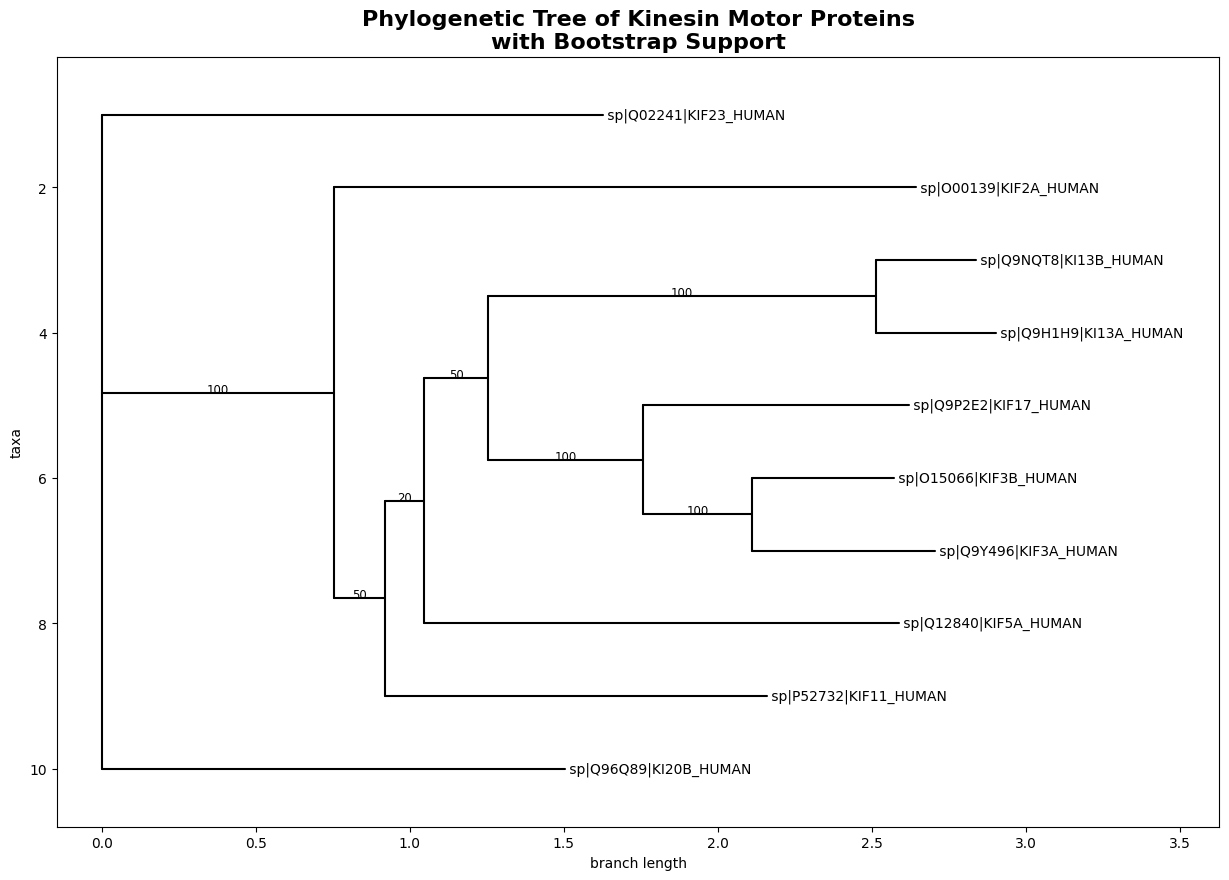

In [22]:
!raxmlHPC \
-s kinesin_motor_aligned.phy \
-n kinesin_motor_bootstrap \
-m PROTCATJTT \
-p 12345 \
-x 12345 \
-# 20 \
-f a

from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(
    "RAxML_bipartitions.kinesin_motor_bootstrap",
    "newick"
)

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)

ax.set_title(
    "Phylogenetic Tree of Kinesin Motor Proteins\nwith Bootstrap Support",
    fontsize=16,
    fontweight='bold'
)

Phylo.draw(
    tree,
    axes=ax,
    branch_labels=lambda c: c.confidence
)

plt.show()

Use raxml with AVX support (1 cpus)

You can specify the number of threads to run via -T numberOfThreads
NumberOfThreads must be set to an integer value greater than 1

RAxML, will now set the number of threads automatically to 2 !

RAxML output files with the run ID <kinesin14_bootstrap> already exist 
in directory /content/ ...... exiting


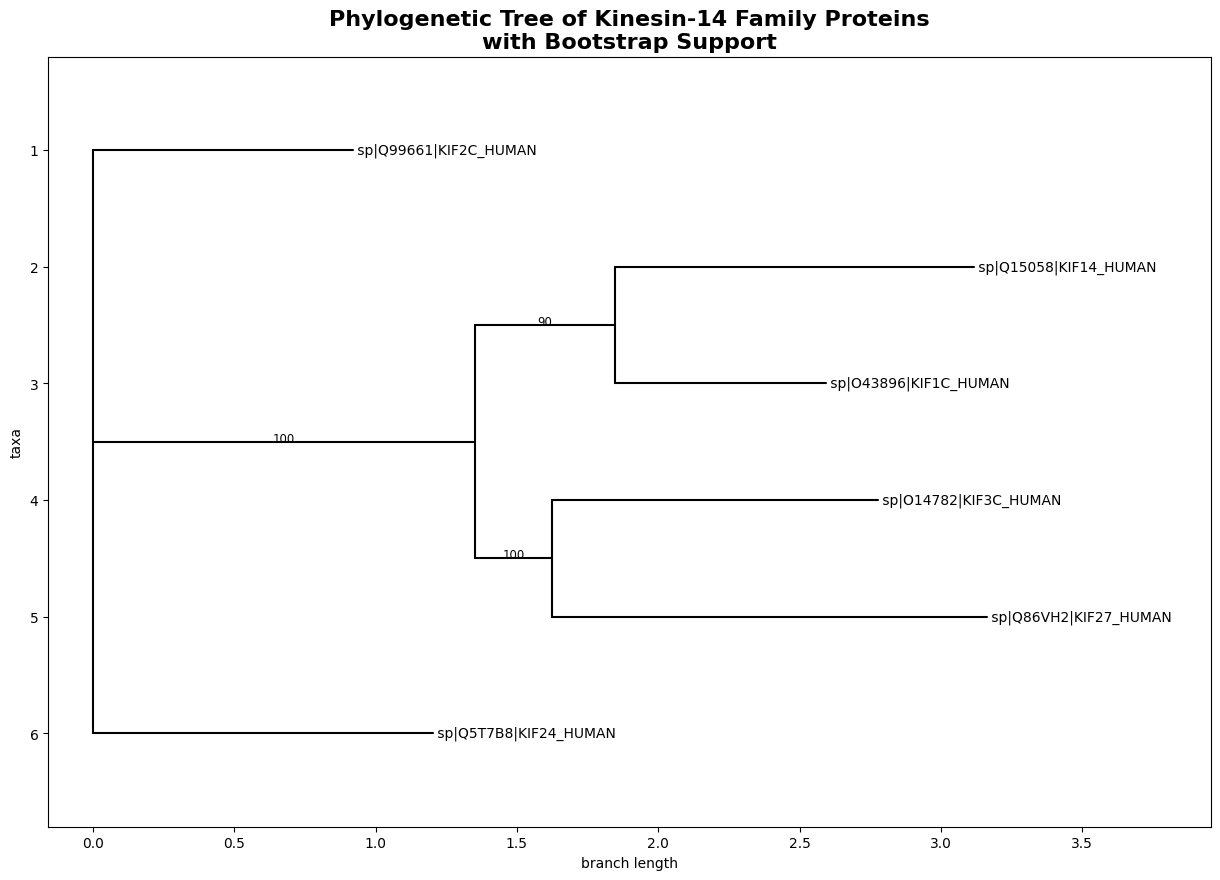

In [21]:
!raxmlHPC \
-s kinesin14_aligned.phy \
-n kinesin14_bootstrap \
-m PROTCATJTT \
-p 12345 \
-x 12345 \
-# 20 \
-f a


from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(
    "RAxML_bipartitions.kinesin14_bootstrap",
    "newick"
)

fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1,1,1)

ax.set_title(
    "Phylogenetic Tree of Kinesin-14 Family Proteins\nwith Bootstrap Support",
    fontsize=16,
    fontweight='bold'
)

Phylo.draw(
    tree,
    axes=ax,
    branch_labels=lambda c: c.confidence
)

plt.show()